# Homework 1

**Name:** Raj Vora

**USC ID:** 9094527849

<style>
@media print {
    .jp-InputArea-editor, .highlight, .jp-OutputArea-output {
        overflow: visible !important;
    }
    .highlight pre, .jp-OutputArea-output pre {
        white-space: pre-wrap !important;
        overflow-wrap: anywhere !important;
        font-size: 8pt !important;
    }
    .jp-RenderedHTMLCommon table.dataframe {
        display: table !important;
        width: 100% !important;
        table-layout: fixed !important;
        font-size: 8pt !important;
    }
    table.dataframe th, table.dataframe td {
        white-space: normal !important;
        overflow-wrap: anywhere !important;
        padding: 2px 3px !important;
    }
}
</style>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style="whitegrid")

## 1(a) Data

In [ ]:
features = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "grade_of_spondylolisthesis",
]
data = pd.read_csv("vertebral_column_data/column_2C.dat", sep=r"\s+", names=features + ["label"])
data["Class"] = data["label"].map({"NO": 0, "AB": 1})
data = data.drop(columns="label")

display(data.head())
display(data["Class"].value_counts().sort_index().rename("count").to_frame())
print(f"Shape: {data.shape}")

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,Class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


,count
Class,
0,100
1,210


Shape: (310, 7)


## 1(b) Pre-processing and exploratory data analysis
### i. Scatterplots

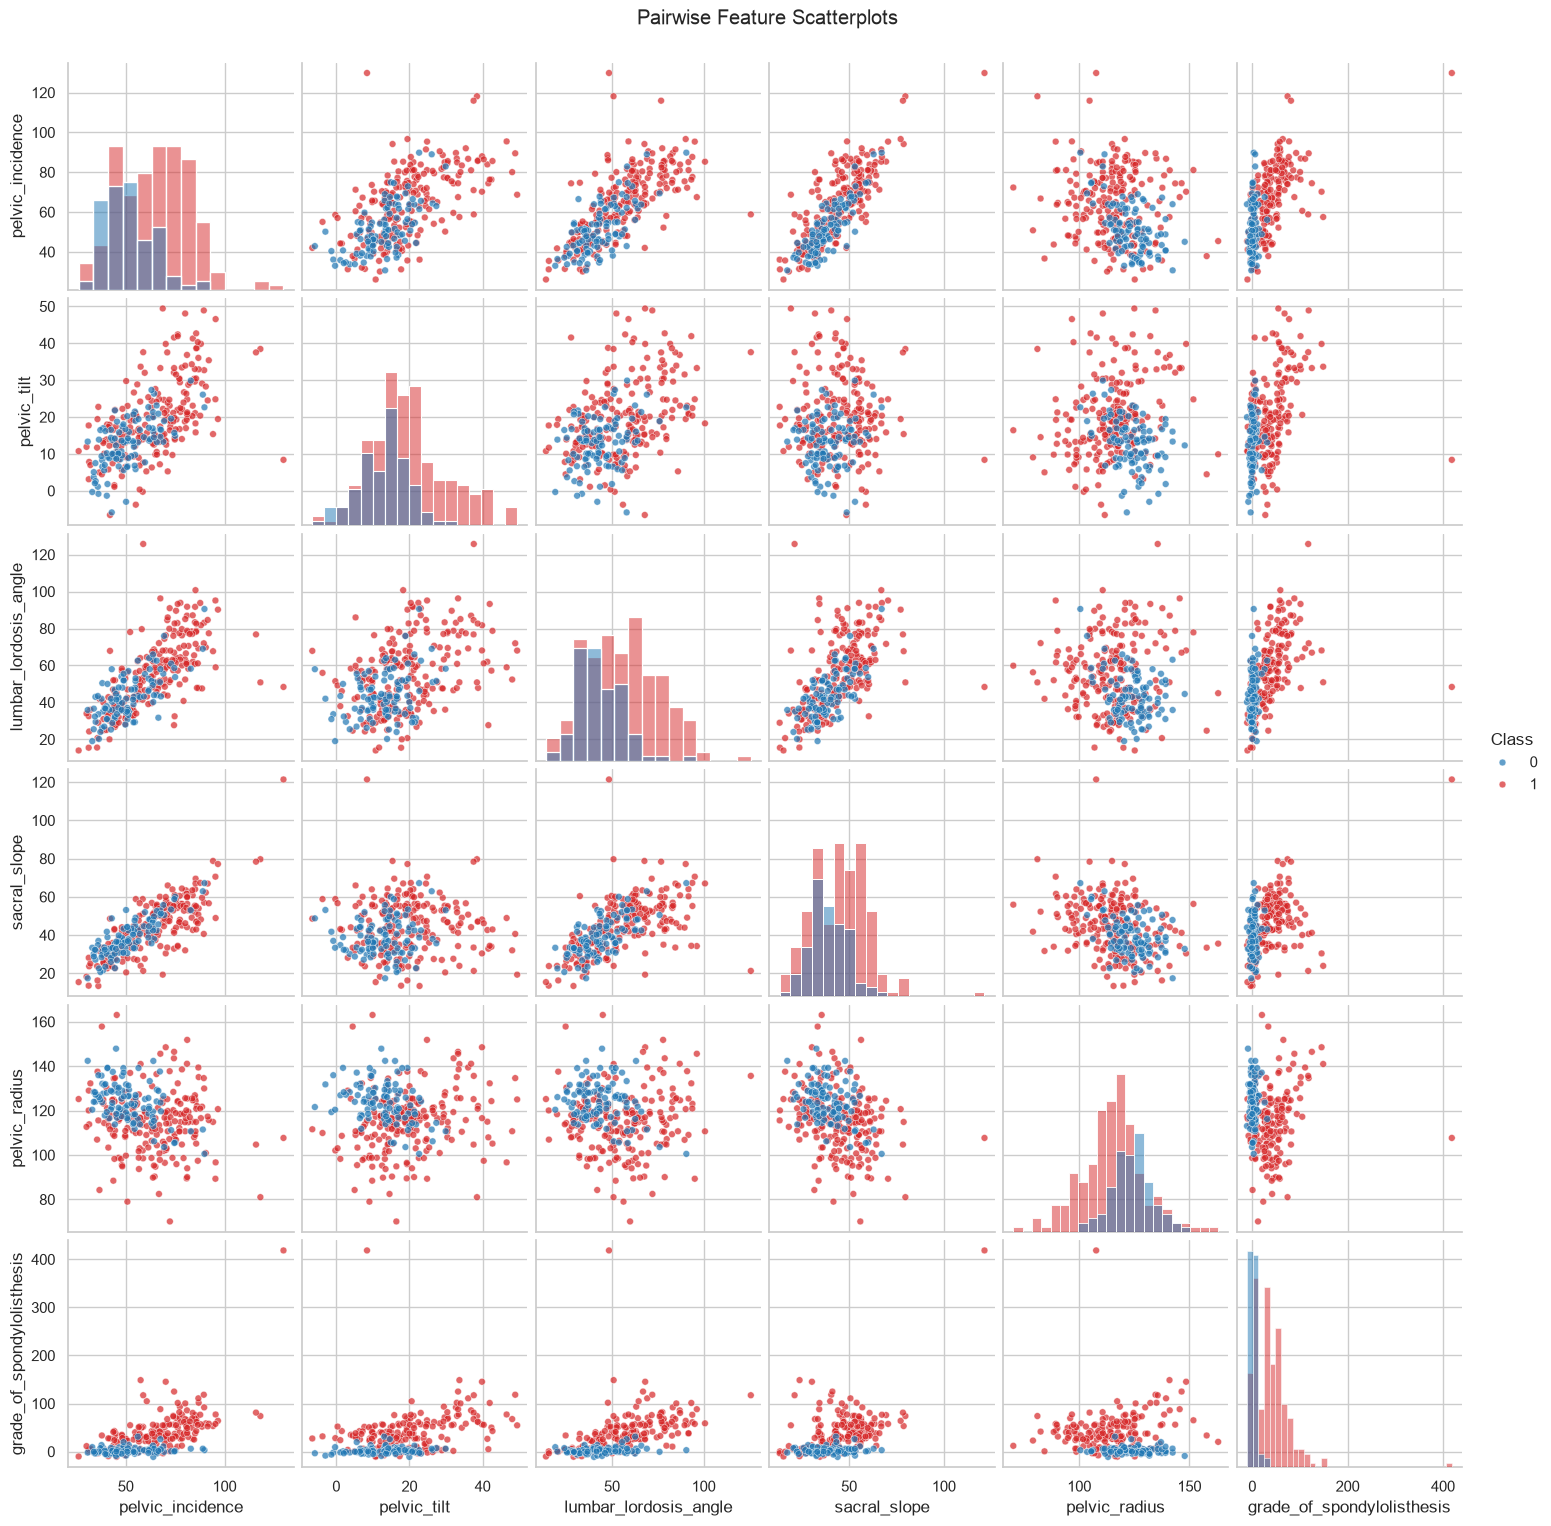

In [ ]:
palette = {0: "#1f77b4", 1: "#d62728"}
scatterplot = sns.pairplot(
    data,
    vars=features,
    hue="Class",
    palette=palette,
    diag_kind="hist",
    plot_kws={"alpha": 0.7, "s": 24},
)
scatterplot.fig.suptitle("Pairwise Feature Scatterplots", y=1.02)
plt.show()

### ii. Boxplots

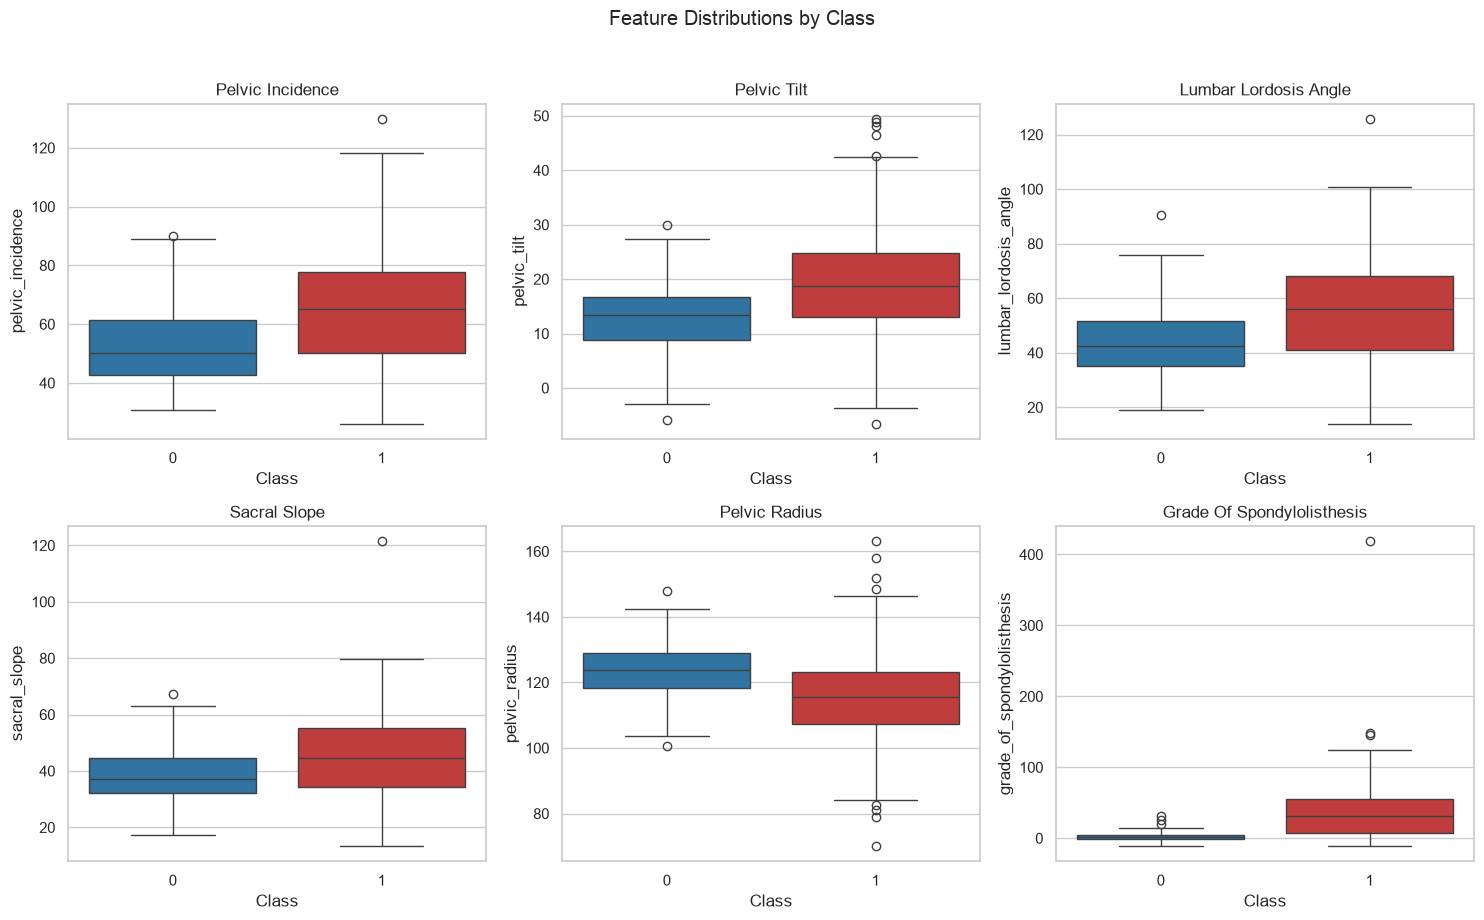

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i in range(6):
    feature = features[i]
    ax = axes.flat[i]
    sns.boxplot(data=data, x="Class", y=feature, hue="Class", palette=palette, legend=False, ax=ax)
    ax.set_title(feature.replace("_", " ").title())
fig.suptitle("Feature Distributions by Class", y=1.02)
fig.tight_layout()
plt.show()

### iii. Training and test sets

In [ ]:
class_0 = data[data["Class"] == 0].reset_index(drop=True)
class_1 = data[data["Class"] == 1].reset_index(drop=True)

train = pd.concat([class_0.iloc[:70], class_1.iloc[:140]], ignore_index=True)
test = pd.concat([class_0.iloc[70:], class_1.iloc[140:]], ignore_index=True)

X_train = train[features]
y_train = train["Class"]
X_test = test[features]
y_test = test["Class"]

split_summary = pd.DataFrame({
    "training": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
display(split_summary)

,training,test
Class,,
0,70,30
1,140,70


## 1(c) Euclidean KNN
### i–ii. Model selection and evaluation

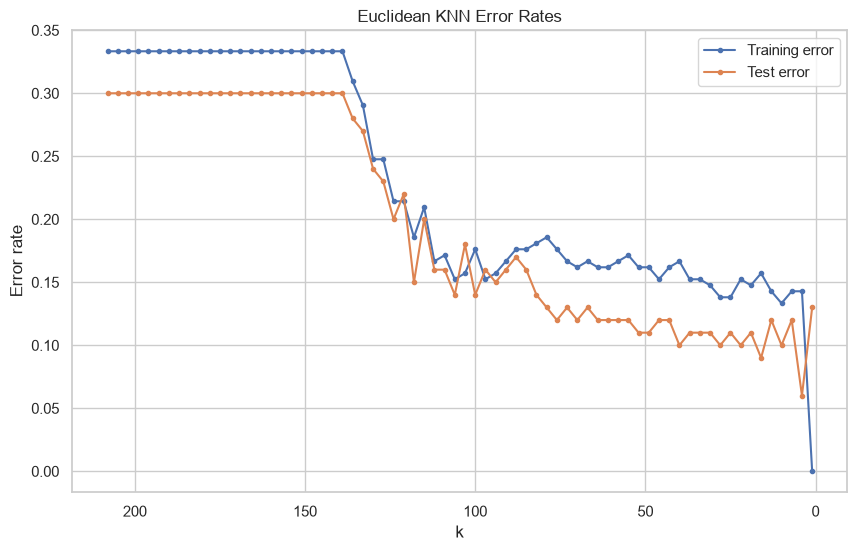

Best k: 4
Best test error: 0.0600


In [ ]:
k_values = np.arange(208, 0, -3)
records = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=int(k), metric="euclidean")
    model.fit(X_train, y_train)
    records.append({
        "k": int(k),
        "train_error": 1 - model.score(X_train, y_train),
        "test_error": 1 - model.score(X_test, y_test),
    })

euclidean_results = pd.DataFrame(records)
best_row = euclidean_results.loc[euclidean_results["test_error"].idxmin()]
best_k = int(best_row["k"])
best_test_error = best_row["test_error"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(euclidean_results["k"], euclidean_results["train_error"], marker="o", markersize=3, label="Training error")
ax.plot(euclidean_results["k"], euclidean_results["test_error"], marker="o", markersize=3, label="Test error")
ax.set(xlabel="k", ylabel="Error rate", title="Euclidean KNN Error Rates")
ax.invert_xaxis()
ax.legend()
plt.show()

print(f"Best k: {best_k}")
print(f"Best test error: {best_test_error:.4f}")

In [ ]:
best_euclidean_model = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
best_euclidean_model.fit(X_train, y_train)
y_pred = best_euclidean_model.predict(X_test)
confusion_values = confusion_matrix(y_test, y_pred)
tn = confusion_values[0, 0]
fp = confusion_values[0, 1]
fn = confusion_values[1, 0]
tp = confusion_values[1, 1]

true_positive_rate = recall_score(y_test, y_pred)
true_negative_rate = tn / (tn + fp)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metric_summary = pd.DataFrame({
    "metric": ["true positive rate", "true negative rate", "precision", "F1-score"],
    "value": [true_positive_rate, true_negative_rate, precision, f1],
})

confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)
display(confusion)
display(metric_summary)

,Predicted 0,Predicted 1
Actual 0,25,5
Actual 1,1,69


,metric,value
0,true positive rate,0.985714
1,true negative rate,0.833333
2,precision,0.932432
3,F1-score,0.958333


### iii. Learning curve

,N,best_k,test_error
0,10,1,0.25
1,20,6,0.20
2,30,1,0.22
3,40,11,0.25
4,50,26,0.30
5,60,21,0.29
6,70,26,0.29
7,80,31,0.29
8,90,41,0.29
9,100,6,0.25


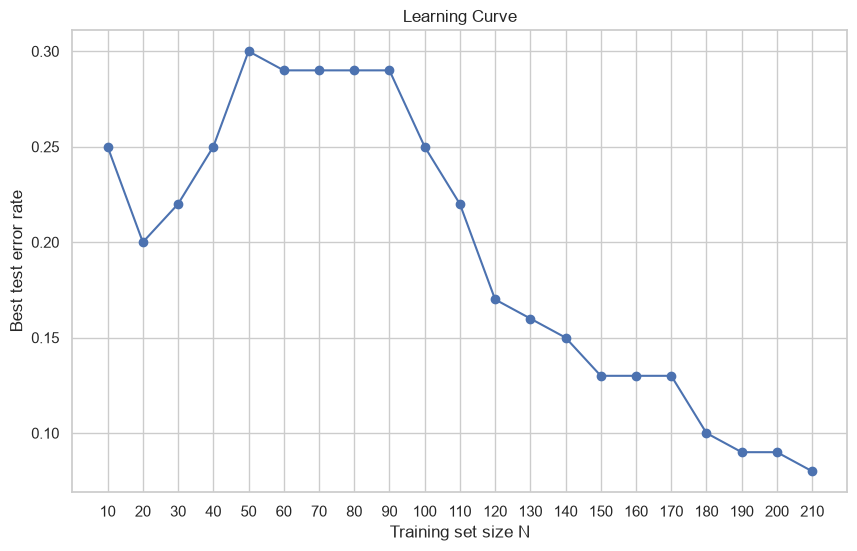

In [ ]:
learning_records = []

for n in range(10, 211, 10):
    n_class_0 = n // 3
    subset_class_0 = train[train["Class"] == 0].iloc[:n_class_0]
    subset_class_1 = train[train["Class"] == 1].iloc[:n - n_class_0]
    subset = pd.concat([subset_class_0, subset_class_1])
    X_subset = subset[features]
    y_subset = subset["Class"]
    possible_k = list(range(1, n, 5))
    errors = []
    for k in possible_k:
        model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
        model.fit(X_subset, y_subset)
        errors.append(1 - model.score(X_test, y_test))
    best_subset_error = min(errors)
    best_subset_k = possible_k[errors.index(best_subset_error)]
    learning_records.append({"N": n, "best_k": best_subset_k, "test_error": best_subset_error})

learning_curve = pd.DataFrame(learning_records)
display(learning_curve)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(learning_curve["N"], learning_curve["test_error"], marker="o")
ax.set(xlabel="Training set size N", ylabel="Best test error rate", title="Learning Curve")
ax.set_xticks(learning_curve["N"])
plt.show()

## 1(d) Alternative distance metrics

In [ ]:
alternative_k_values = list(range(1, 197, 5))

def evaluate_knn(metric, weights="uniform", metric_params=None):
    results = []
    for k in alternative_k_values:
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            weights=weights,
            metric_params=metric_params,
            algorithm="brute",
        )
        model.fit(X_train, y_train)
        results.append({
            "k": k,
            "train_error": 1 - model.score(X_train, y_train),
            "test_error": 1 - model.score(X_test, y_test),
        })
    results = pd.DataFrame(results)
    best = results.loc[results["test_error"].idxmin()]
    return results, best

manhattan_results, manhattan_best = evaluate_knn("manhattan")
chebyshev_results, chebyshev_best = evaluate_knn("chebyshev")

covariance = np.cov(X_train, rowvar=False)
inverse_covariance = np.linalg.pinv(covariance)
mahalanobis_results, mahalanobis_best = evaluate_knn(
    "mahalanobis",
    metric_params={"VI": inverse_covariance},
)

In [ ]:
manhattan_k = int(manhattan_best["k"])
minkowski_records = []

for i in range(1, 11):
    log10_p = i / 10
    p = 10 ** log10_p
    model = KNeighborsClassifier(n_neighbors=manhattan_k, metric="minkowski", p=p, algorithm="brute")
    model.fit(X_train, y_train)
    minkowski_records.append({
        "log10(p)": round(log10_p, 1),
        "p": p,
        "k": manhattan_k,
        "train_error": 1 - model.score(X_train, y_train),
        "test_error": 1 - model.score(X_test, y_test),
    })

minkowski_results = pd.DataFrame(minkowski_records)
minkowski_best = minkowski_results.loc[minkowski_results["test_error"].idxmin()]
display(minkowski_results)

,log10(p),p,k,train_error,test_error
0,0.1,1.258925,6,0.138095,0.09
1,0.2,1.584893,6,0.147619,0.09
2,0.3,1.995262,6,0.152381,0.08
3,0.4,2.511886,6,0.152381,0.08
4,0.5,3.162278,6,0.147619,0.08
5,0.6,3.981072,6,0.152381,0.06
6,0.7,5.011872,6,0.152381,0.07
7,0.8,6.309573,6,0.147619,0.08
8,0.9,7.943282,6,0.147619,0.09
9,1.0,10.000000,6,0.133333,0.09


In [ ]:
distance_summary = pd.DataFrame([
    {"distance": "Manhattan", "best_k": int(manhattan_best["k"]), "parameter": "p = 1", "test_error": manhattan_best["test_error"]},
    {"distance": "Minkowski", "best_k": int(minkowski_best["k"]), "parameter": f"log10(p) = {minkowski_best['log10(p)']:.1f}", "test_error": minkowski_best["test_error"]},
    {"distance": "Chebyshev", "best_k": int(chebyshev_best["k"]), "parameter": "p = infinity", "test_error": chebyshev_best["test_error"]},
    {"distance": "Mahalanobis", "best_k": int(mahalanobis_best["k"]), "parameter": "pseudoinverse", "test_error": mahalanobis_best["test_error"]},
])
display(distance_summary)

,distance,best_k,parameter,test_error
0,Manhattan,6,p = 1,0.11
1,Minkowski,6,log10(p) = 0.6,0.06
2,Chebyshev,16,p = infinity,0.08
3,Mahalanobis,1,pseudoinverse,0.17


## 1(e) Weighted voting

In [ ]:
weighted_euclidean_results, weighted_euclidean_best = evaluate_knn("euclidean", weights="distance")
weighted_manhattan_results, weighted_manhattan_best = evaluate_knn("manhattan", weights="distance")
weighted_chebyshev_results, weighted_chebyshev_best = evaluate_knn("chebyshev", weights="distance")

weighted_summary = pd.DataFrame([
    {"distance": "Euclidean", "best_k": int(weighted_euclidean_best["k"]), "test_error": weighted_euclidean_best["test_error"]},
    {"distance": "Manhattan", "best_k": int(weighted_manhattan_best["k"]), "test_error": weighted_manhattan_best["test_error"]},
    {"distance": "Chebyshev", "best_k": int(weighted_chebyshev_best["k"]), "test_error": weighted_chebyshev_best["test_error"]},
])
display(weighted_summary)

,distance,best_k,test_error
0,Euclidean,6,0.10
1,Manhattan,26,0.10
2,Chebyshev,16,0.11


## 1(f) Lowest training error

In [ ]:
lowest_training_error = min(
    euclidean_results["train_error"].min(),
    manhattan_results["train_error"].min(),
    minkowski_results["train_error"].min(),
    chebyshev_results["train_error"].min(),
    mahalanobis_results["train_error"].min(),
    weighted_euclidean_results["train_error"].min(),
    weighted_manhattan_results["train_error"].min(),
    weighted_chebyshev_results["train_error"].min(),
)
print(f"Lowest training error rate: {lowest_training_error:.4f}")

Lowest training error rate: 0.0000
